# Introducción a PyTorch — Clasificación de Razas de Perros

## Contenido
- Comenzando con PyTorch  
- Carga y procesamiento de datos (Dog Breeds Dataset)  
- Construcción de modelos  
- Función de pérdida y optimizador  
- Entrenamiento y evaluación

## Descripción general

El aprendizaje profundo (deep learning) es un campo del aprendizaje automático que utiliza redes neuronales masivas, grandes volúmenes de datos y computación acelerada en GPUs. En este cuaderno aplicaremos los fundamentos de PyTorch para clasificar **8 razas de perros** usando una red neuronal convolucional (CNN) entrenada desde cero.

**Dataset:** 541 imágenes distribuidas en 8 clases: beagle, bulldog, dalmatian, german-shepherd, husky, labrador-retriever, poodle, rottweiler.

## ¿Qué es CUDA?

CUDA es un marco de trabajo desarrollado por NVIDIA que nos permite utilizar la Computación de Propósito General en Unidades de Procesamiento Gráfico (GPGPU). Casi todos los frameworks de aprendizaje profundo aprovechan CUDA para ejecutar instrucciones en las GPUs, logrando aceleraciones de 10x–100x frente a la CPU.

## PyTorch

[PyTorch](https://pytorch.org) es un framework de código abierto en Python desarrollado por el equipo de Facebook AI Research. Puede considerarse una extensión de NumPy que incluye:
- Soporte para GPU mediante tensores en CUDA
- Diferenciación automática (autograd) para calcular gradientes
- Herramientas para definir y entrenar redes neuronales

## Comenzando con PyTorch

In [4]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


In [5]:
# Detectar si hay GPU disponible y definir el dispositivo de trabajo
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("GPU disponible:", torch.cuda.get_device_name(0))
    print("Número de GPUs:", torch.cuda.device_count())
else:
    device = torch.device("cpu")
    print("GPU no disponible — usando CPU")

GPU disponible: NVIDIA GeForce RTX 5060 Ti
Número de GPUs: 1


## Tensores en PyTorch

Los tensores son la estructura de datos fundamental en PyTorch. Son una generalización de vectores y matrices a N dimensiones.

| Concepto | Dimensiones | Ejemplo |
|----------|-------------|--------|
| Escalar  | 0D | `5` |
| Vector   | 1D | `[1, 2, 3]` |
| Matriz   | 2D | `[[1,2],[3,4]]` |
| Imagen color | 3D | `(3, 64, 64)` |
| Batch de imágenes | 4D | `(batch, 3, 64, 64)` |

| NumPy | PyTorch | Descripción |
|-------|---------|-------------|
| `np.ones(.)` | `torch.ones(.)` | Crea un tensor de unos |
| `np.zeros(.)` | `torch.zeros(.)` | Crea un tensor de ceros |
| `np.random.rand(.)` | `torch.rand(.)` | Crea un tensor aleatorio uniforme |
| `np.array(.)` | `torch.tensor(.)` | Crea tensor desde valores dados |
| `x.shape` | `x.shape` o `x.size()` | Obtiene la forma del tensor |

In [6]:
# Crear tensores básicos
x_rand = torch.rand(2, 3)
print("Tensor aleatorio:\n", x_rand)

x_ones = torch.ones(2, 3)
print("\nTensor de unos:\n", x_ones, "\nTipo:", x_ones.dtype)

Tensor aleatorio:
 tensor([[0.6129, 0.3419, 0.4240],
        [0.2295, 0.5719, 0.0133]])

Tensor de unos:
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 
Tipo: torch.float32


In [7]:
# Crear tensor con tipo de dato específico
x_int = torch.ones(2, 3, dtype=torch.int16)
print("Tensor int16:\n", x_int, "\nTipo:", x_int.dtype)

# Cambiar el tipo de dato
x_float = x_int.type(torch.float32)
print("\nConvertido a float32, tipo:", x_float.dtype)

Tensor int16:
 tensor([[1, 1, 1],
        [1, 1, 1]], dtype=torch.int16) 
Tipo: torch.int16

Convertido a float32, tipo: torch.float32


In [8]:
# Tensor con distribución normal (media=0, varianza=1)
r_val = torch.randn(3, 4)
print("Tensor normal:\n", r_val)

# Tensor con enteros en un rango
rng_val = torch.randint(0, 10, (3, 4))
print("\nTensor entero [0,10):\n", rng_val)

Tensor normal:
 tensor([[ 0.4276,  1.0619,  0.1437, -0.3056],
        [ 1.8303,  0.2005, -0.1148, -0.4390],
        [-0.4664,  0.1656, -0.7200, -0.3386]])

Tensor entero [0,10):
 tensor([[3, 6, 8, 9],
        [8, 5, 9, 4],
        [3, 6, 4, 8]])


In [9]:
# Convertir tensor a NumPy y viceversa
x = torch.rand(2, 3)
y_np = x.numpy()        # tensor → numpy
print("NumPy:", y_np.dtype)

arr = np.ones((2, 3), dtype=np.float32)
y_t = torch.from_numpy(arr)  # numpy → tensor
print("Tensor:", y_t.dtype)

NumPy: float32
Tensor: torch.float32


In [10]:
# Mover tensores entre CPU y GPU
x = torch.tensor([2.3, 5.8])
print("Dispositivo inicial:", x.device)

x = x.to(device)  # mover al dispositivo definido arriba (GPU o CPU)
print("Después de .to(device):", x.device)

Dispositivo inicial: cpu
Después de .to(device): cuda:0


## Carga y procesamiento de datos

El dataset **Dog Breeds** contiene imágenes JPG en color organizadas en carpetas por raza. No viene dividido en train/val, así que lo dividiremos nosotros usando `random_split`.

**Estructura del dataset:**
```
dog-breeds/
├── beagle/          (83 imágenes)
├── bulldog/         (76 imágenes)
├── dalmatian/       (51 imágenes)
├── german-shepherd/ (76 imágenes)
├── husky/           (71 imágenes)
├── labrador-retriever/ (50 imágenes)
├── poodle/          (56 imágenes)
└── rottweiler/      (78 imágenes)
```
**Total: 541 imágenes — 8 clases**

### Transformaciones de datos

Con solo 541 imágenes, el aumento de datos (*data augmentation*) es crucial para evitar sobreajuste.

- **`Resize(64, 64)`**: estandariza el tamaño (las imágenes vienen en diferentes resoluciones)
- **`RandomHorizontalFlip`**: volteo horizontal aleatorio → duplica variedad
- **`RandomRotation(15)`**: rotación aleatoria ±15° → más variedad
- **`ColorJitter`**: variaciones de brillo/contraste → robustez a iluminación
- **`ToTensor`**: convierte PIL Image a tensor float32 en rango [0, 1]
- **`Normalize`**: centra y escala usando la media/std de ImageNet (estándar para imágenes naturales)

In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

# Ruta al dataset (relativa al notebook)
data_path = "./dog-breeds"

# Transformaciones para entrenamiento (con aumento de datos)
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transformaciones para validación (sin aumento, solo estandarizar)
val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [12]:
# Cargar el dataset con ImageFolder
# ImageFolder asigna automáticamente un índice a cada carpeta (orden alfabético)
full_dataset_train = datasets.ImageFolder(data_path, transform=train_transforms)
full_dataset_val   = datasets.ImageFolder(data_path, transform=val_transforms)

# Clases detectadas automáticamente
class_names = full_dataset_train.classes
num_classes = len(class_names)
print("Clases:", class_names)
print("Número de clases:", num_classes)
print("Total de imágenes:", len(full_dataset_train))

# Mapeo clase → índice
print("\nÍndices:", full_dataset_train.class_to_idx)

Clases: ['beagle', 'bulldog', 'dalmatian', 'german-shepherd', 'husky', 'labrador-retriever', 'poodle', 'rottweiler']
Número de clases: 8
Total de imágenes: 541

Índices: {'beagle': 0, 'bulldog': 1, 'dalmatian': 2, 'german-shepherd': 3, 'husky': 4, 'labrador-retriever': 5, 'poodle': 6, 'rottweiler': 7}


In [13]:
# División train/val: 80% entrenamiento, 20% validación
# Usamos la misma semilla para que ambos subsets tengan exactamente los mismos índices
n_total = len(full_dataset_train)
n_train = int(0.8 * n_total)
n_val   = n_total - n_train

# Generar índices aleatorios con semilla fija para reproducibilidad
torch.manual_seed(42)
indices = torch.randperm(n_total).tolist()

train_idx = indices[:n_train]
val_idx   = indices[n_train:]

# Crear subsets: train con augmentation, val sin augmentation
train_ds = Subset(full_dataset_train, train_idx)
val_ds   = Subset(full_dataset_val,   val_idx)

print(f"Imágenes de entrenamiento: {len(train_ds)}")
print(f"Imágenes de validación:    {len(val_ds)}")

Imágenes de entrenamiento: 432
Imágenes de validación:    109


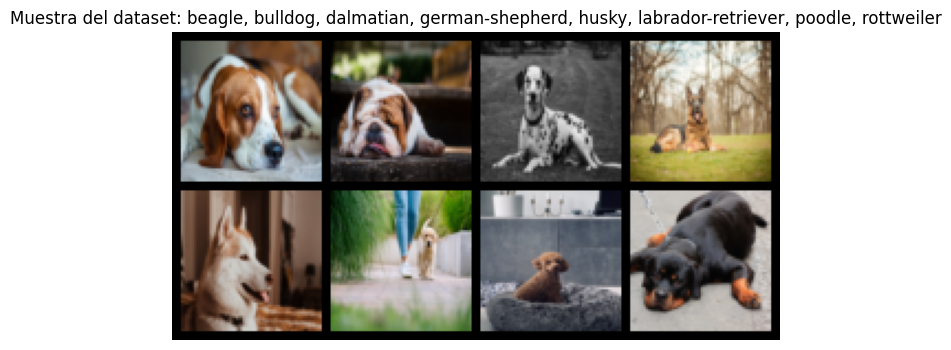

In [14]:
# Visualizar imágenes de muestra del dataset (sin normalización para que se vean bien)
from torchvision import utils

viz_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])
viz_dataset = datasets.ImageFolder(data_path, transform=viz_transforms)

# Tomar una imagen por clase
samples = []
labels_shown = []
seen = {}
for img, label in viz_dataset:
    if label not in seen:
        seen[label] = True
        samples.append(img)
        labels_shown.append(class_names[label])
    if len(samples) == num_classes:
        break

# Mostrar cuadrícula
grid = utils.make_grid(samples, nrow=4, padding=4)
npimg = grid.numpy()
plt.figure(figsize=(12, 4))
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.title("Muestra del dataset: " + ", ".join(labels_shown))
plt.axis('off')
plt.show()

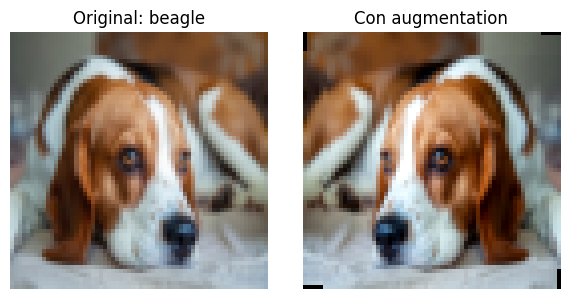

In [15]:
# Mostrar imagen original vs imagen con transformaciones de entrenamiento
viz_no_transform = datasets.ImageFolder(data_path)
img_pil, label = viz_no_transform[0]

# Aplicar solo resize para visualización
img_resized = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])(img_pil)

# Aplicar transformaciones de entrenamiento
img_augmented = train_transforms(img_pil)
# Denormalizar para mostrar
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_aug_show = (img_augmented * std + mean).clamp(0, 1)

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(img_resized.permute(1, 2, 0))
plt.title(f"Original: {class_names[label]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_aug_show.permute(1, 2, 0))
plt.title("Con augmentation")
plt.axis('off')
plt.tight_layout()
plt.show()

### Creación de DataLoaders

El `DataLoader` divide el dataset en *batches* y los baraja en cada época. Esto permite:
- Entrenar con gradientes más estables (promedio sobre un batch)
- Procesar datos en paralelo
- Caber en memoria GPU aunque el dataset sea grande

In [16]:
# Crear DataLoaders
# shuffle=True en train para que el modelo no vea siempre el mismo orden
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=16, shuffle=False)

# Verificar forma del primer batch
for xb, yb in train_dl:
    print("Forma del batch de imágenes:", xb.shape)  # (16, 3, 64, 64)
    print("Forma del batch de etiquetas:", yb.shape) # (16,)
    print("Ejemplo de etiquetas:", [class_names[y] for y in yb[:4]])
    break

Forma del batch de imágenes: torch.Size([16, 3, 64, 64])
Forma del batch de etiquetas: torch.Size([16])
Ejemplo de etiquetas: ['beagle', 'rottweiler', 'beagle', 'rottweiler']


## Construcción del Modelo

### ¿Por qué una CNN para imágenes?

Las redes neuronales convolucionales (CNN) detectan **patrones locales** (bordes, texturas, formas) independientemente de su posición en la imagen, usando muchos menos parámetros que capas densas.

**Arquitectura DogNet:**
```
Entrada: 3 × 64 × 64  (imagen RGB)
  ↓  Conv2d(3→32, k=3, p=1) + ReLU + MaxPool(2)  →  32 × 32 × 32
  ↓  Conv2d(32→64, k=3, p=1) + ReLU + MaxPool(2) →  64 × 16 × 16
  ↓  Conv2d(64→128, k=3, p=1) + ReLU + MaxPool(2)→  128 × 8 × 8
  ↓  Flatten                                      →  8192
  ↓  Dropout(0.5) + Linear(8192→512) + ReLU       →  512
  ↓  Dropout(0.3) + Linear(512→8)                 →  8 clases (logits)
```

**Nota:** Con `padding=1` y `kernel=3`, las dimensiones espaciales se conservan antes del MaxPool. Por eso el math es limpio: 64→32→16→8 (cada MaxPool(2) divide por 2).

In [17]:
# Demo: capa lineal
from torch import nn

input_tensor = torch.randn(16, 8192)  # batch de 16, 8192 features
linear_layer = nn.Linear(8192, 512)
output = linear_layer(input_tensor)
print("Entrada:", input_tensor.shape, "→ Salida:", output.shape)

Entrada: torch.Size([16, 8192]) → Salida: torch.Size([16, 512])


In [18]:
# Demo: modelo simple con nn.Sequential
modelo_simple = nn.Sequential(
    nn.Linear(8192, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 8)
)
print(modelo_simple)

Sequential(
  (0): Linear(in_features=8192, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=512, out_features=8, bias=True)
)


In [19]:
import torch.nn.functional as F

class DogNet(nn.Module):
    def __init__(self, num_classes=8):
        super(DogNet, self).__init__()

        # Bloque 1: 3 canales entrada (RGB) → 32 mapas de características
        # padding=1 mantiene el tamaño espacial antes del MaxPool
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)

        # Bloque 2: 32 → 64 mapas
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Bloque 3: 64 → 128 mapas
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Capas completamente conectadas
        # Después de 3 MaxPool(2) sobre imagen 64×64: 64/2/2/2 = 8 → 128×8×8 = 8192
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_classes)

        # Dropout: desactiva neuronas aleatoriamente durante el entrenamiento
        # Regularización para evitar sobreajuste con dataset pequeño
        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.3)

    def forward(self, x):
        # Bloque convolucional 1: 3×64×64 → 32×32×32
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)

        # Bloque convolucional 2: 32×32×32 → 64×16×16
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)

        # Bloque convolucional 3: 64×16×16 → 128×8×8
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2, 2)

        # Aplanar: 128×8×8 = 8192 valores por imagen
        x = x.view(-1, 128 * 8 * 8)

        # Capas densas con dropout
        x = self.dropout1(x)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)

        # Retorna logits crudos — CrossEntropyLoss aplica softmax internamente
        return x

In [20]:
# Crear e inspeccionar el modelo
model = DogNet(num_classes=8)
print(model)

DogNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=8, bias=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (dropout2): Dropout(p=0.3, inplace=False)
)


In [21]:
# Mover el modelo al dispositivo (GPU o CPU)
print("Dispositivo antes:", next(model.parameters()).device)
model = model.to(device)
print("Dispositivo después:", next(model.parameters()).device)

Dispositivo antes: cpu
Dispositivo después: cuda:0


In [22]:
# Resumen del modelo con torchsummary
# Si no está instalado: pip install torchsummary
try:
    from torchsummary import summary
    summary(model, input_size=(3, 64, 64))
except ImportError:
    print("Instala torchsummary con: pip install torchsummary")
    # Conteo manual de parámetros
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parámetros entrenables: {total:,}")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]             896
            Conv2d-2           [-1, 64, 32, 32]          18,496
            Conv2d-3          [-1, 128, 16, 16]          73,856
           Dropout-4                 [-1, 8192]               0
            Linear-5                  [-1, 512]       4,194,816
           Dropout-6                  [-1, 512]               0
            Linear-7                    [-1, 8]           4,104
Total params: 4,292,168
Trainable params: 4,292,168
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.05
Forward/backward pass size (MB): 1.82
Params size (MB): 16.37
Estimated Total Size (MB): 18.24
----------------------------------------------------------------


## Función de Pérdida y Optimizador

### CrossEntropyLoss

`CrossEntropyLoss` combina `log_softmax` + `NLLLoss` en un solo paso. Es la función estándar para clasificación multi-clase.

**Intuición:** si el modelo asigna probabilidad 0.01 a la clase correcta, la pérdida es alta (−log(0.01) ≈ 4.6). Si asigna 0.99, la pérdida es casi cero (−log(0.99) ≈ 0.01).

**Ventaja sobre NLLLoss:** no requiere `log_softmax` al final del modelo, lo que simplifica la definición de `forward`.

In [23]:
from torch import nn, optim

# CrossEntropyLoss para clasificación multi-clase
# reduction="sum" acumula pérdidas; se divide entre n_muestras al final
loss_func = nn.CrossEntropyLoss(reduction="sum")

# Verificar pérdida en el primer batch
for xb, yb in train_dl:
    xb = xb.to(device)
    yb = yb.to(device)
    out = model(xb)
    loss = loss_func(out, yb)
    print(f"Pérdida inicial (primer batch): {loss.item():.4f}")
    print(f"Logits shape: {out.shape}")
    break

Pérdida inicial (primer batch): 33.3889
Logits shape: torch.Size([16, 8])


In [24]:
# Optimizador Adam con tasa de aprendizaje 1e-3
# Adam adapta la tasa de aprendizaje por parámetro — más eficiente que SGD puro
opt = optim.Adam(model.parameters(), lr=1e-3)

## Entrenamiento y Evaluación

El ciclo de entrenamiento tiene **3 pasos fijos** por cada batch:

```
1. loss.backward()  →  calcular gradientes (retropropagación)
2. opt.step()       →  actualizar pesos en dirección del gradiente
3. opt.zero_grad()  →  limpiar gradientes para el próximo batch
```

**Por qué `zero_grad()`?** Sin este paso, los gradientes se acumulan entre batches y el entrenamiento diverge.

In [25]:
def metrics_batch(target, output):
    """Calcula el número de predicciones correctas en un batch."""
    # argmax encuentra el índice de la clase con mayor logit
    pred = output.argmax(dim=1, keepdim=True)
    corrects = pred.eq(target.view_as(pred)).sum().item()
    return corrects


def loss_batch(loss_func, xb, yb, yb_h, opt=None):
    """Calcula pérdida y accuracy de un batch. Si opt no es None, actualiza pesos."""
    loss = loss_func(yb_h, yb)
    metric_b = metrics_batch(yb, yb_h)

    if opt is not None:
        loss.backward()   # retropropagación
        opt.step()        # actualizar pesos
        opt.zero_grad()   # limpiar gradientes

    return loss.item(), metric_b


def loss_epoch(model, loss_func, dataset_dl, opt=None):
    """Procesa todos los batches de un DataLoader y devuelve pérdida y accuracy promedio."""
    loss = 0.0
    metric = 0.0
    len_data = len(dataset_dl.dataset)

    for xb, yb in dataset_dl:
        xb = xb.to(device)  # mover batch a GPU/CPU
        yb = yb.to(device)
        yb_h = model(xb)    # forward pass

        loss_b, metric_b = loss_batch(loss_func, xb, yb, yb_h, opt)
        loss   += loss_b
        metric += metric_b

    return loss / len_data, metric / len_data

In [26]:
def train_val(epochs, model, loss_func, opt, train_dl, val_dl):
    """Entrena y valida el modelo durante el número de épocas indicado."""
    history = {"train_loss": [], "val_loss": [], "accuracy": []}

    for epoch in range(epochs):
        # --- Entrenamiento ---
        model.train()  # activa dropout y batchnorm en modo entrenamiento
        train_loss, train_metric = loss_epoch(model, loss_func, train_dl, opt)

        # --- Validación ---
        model.eval()   # desactiva dropout para evaluación
        with torch.no_grad():  # evita calcular gradientes innecesarios
            val_loss, val_metric = loss_epoch(model, loss_func, val_dl)

        accuracy = 100 * val_metric
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["accuracy"].append(accuracy)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Accuracy: {accuracy:.1f}%")

    return history

In [27]:
# Entrenar el modelo — 20 épocas
# Con dataset pequeño (541 imgs) se necesitan más épocas que con MNIST
num_epochs = 20
history = train_val(num_epochs, model, loss_func, opt, train_dl, val_dl)

Epoch  1/20 | Train Loss: 2.0902 | Val Loss: 2.0485 | Accuracy: 11.0%
Epoch  2/20 | Train Loss: 1.9220 | Val Loss: 1.8351 | Accuracy: 31.2%
Epoch  3/20 | Train Loss: 1.7077 | Val Loss: 1.5372 | Accuracy: 45.9%
Epoch  4/20 | Train Loss: 1.5296 | Val Loss: 1.4985 | Accuracy: 40.4%
Epoch  5/20 | Train Loss: 1.4320 | Val Loss: 1.5462 | Accuracy: 43.1%
Epoch  6/20 | Train Loss: 1.2650 | Val Loss: 1.3641 | Accuracy: 56.0%
Epoch  7/20 | Train Loss: 1.1796 | Val Loss: 1.4008 | Accuracy: 54.1%
Epoch  8/20 | Train Loss: 1.0899 | Val Loss: 1.2850 | Accuracy: 56.9%
Epoch  9/20 | Train Loss: 0.9559 | Val Loss: 1.2611 | Accuracy: 57.8%
Epoch 10/20 | Train Loss: 0.9359 | Val Loss: 1.2050 | Accuracy: 61.5%
Epoch 11/20 | Train Loss: 0.7567 | Val Loss: 1.1719 | Accuracy: 61.5%
Epoch 12/20 | Train Loss: 0.7450 | Val Loss: 0.9321 | Accuracy: 69.7%
Epoch 13/20 | Train Loss: 0.6777 | Val Loss: 1.1479 | Accuracy: 65.1%
Epoch 14/20 | Train Loss: 0.5438 | Val Loss: 1.0689 | Accuracy: 67.9%
Epoch 15/20 | Train 

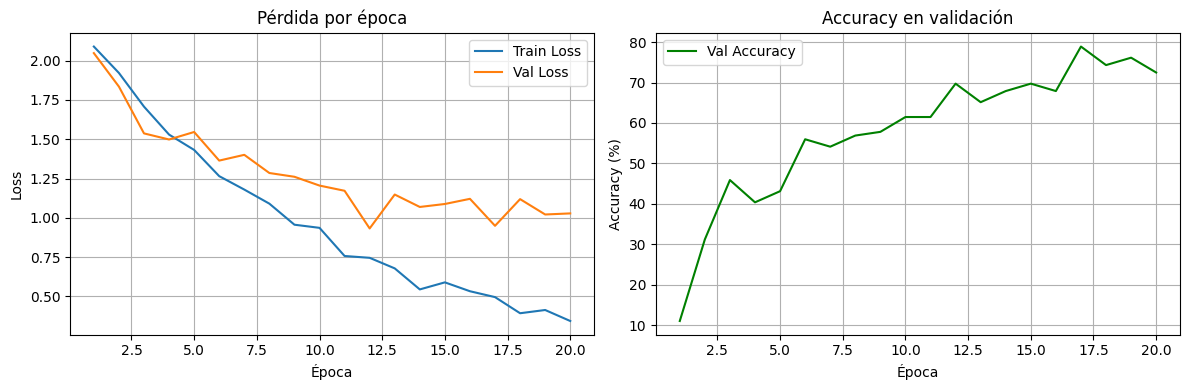

In [28]:
# Visualizar curvas de pérdida y accuracy durante el entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, num_epochs + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss")
axes[0].set_title("Pérdida por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, history["accuracy"], color="green", label="Val Accuracy")
axes[1].set_title("Accuracy en validación")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Guardar y Cargar el Modelo

In [29]:
# Guardar los pesos entrenados
# state_dict contiene solo los tensores de parámetros (sin la arquitectura)
weights_path = "dognet_weights.pt"
torch.save(model.state_dict(), weights_path)
print(f"Pesos guardados en: {weights_path}")

Pesos guardados en: dognet_weights.pt


In [30]:
# Cargar los pesos en un modelo nuevo
_model = DogNet(num_classes=8)
_model.load_state_dict(torch.load(weights_path, map_location=device))
_model = _model.to(device)
_model.eval()
print("Modelo cargado exitosamente")
print(_model)

Modelo cargado exitosamente
DogNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=8, bias=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (dropout2): Dropout(p=0.3, inplace=False)
)


## Despliegue del Modelo — Predicción sobre una imagen

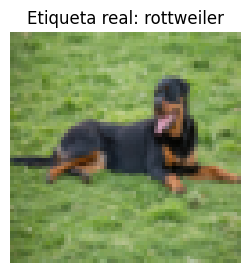

In [31]:
# Seleccionar una imagen del conjunto de validación para hacer una predicción
sample_idx = 5
img_tensor, true_label = val_ds[sample_idx]

# Mostrar la imagen (denormalizar para visualización)
mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_show = (img_tensor * std_t + mean_t).clamp(0, 1)

plt.figure(figsize=(3, 3))
plt.imshow(img_show.permute(1, 2, 0))
plt.title(f"Etiqueta real: {class_names[true_label]}")
plt.axis('off')
plt.show()

In [32]:
# Hacer la predicción
# unsqueeze(0) agrega la dimensión de batch: (3,64,64) → (1,3,64,64)
x = img_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    output = _model(x)                        # logits: (1, 8)

pred_idx = output.argmax(dim=1).item()        # índice de la clase con mayor logit
probs = torch.softmax(output, dim=1)[0]       # probabilidades por clase

print(f"Predicción: {class_names[pred_idx]}")
print(f"Real:       {class_names[true_label]}")
print(f"Correcto:   {'Sí' if pred_idx == true_label else 'No'}")
print("\nProbabilidades por clase:")
for i, (name, prob) in enumerate(zip(class_names, probs)):
    bar = '█' * int(prob.item() * 30)
    print(f"  {name:<22} {prob.item()*100:5.1f}% {bar}")

Predicción: rottweiler
Real:       rottweiler
Correcto:   Sí

Probabilidades por clase:
  beagle                   0.2% 
  bulldog                  0.0% 
  dalmatian                0.0% 
  german-shepherd          5.1% █
  husky                    0.0% 
  labrador-retriever       0.0% 
  poodle                   0.0% 
  rottweiler              94.7% ████████████████████████████
